# DA Mini Project
* 주제 : 온라인 학습 플랫폼 사용자 행동 패턴 분석
* 개요 :
```
이번 프로젝트는 학습 서비스를 이용하는 독자들 중 누가 서비스 구독을 연장할지 예측하기 위한 사전 파악에 초점을 맞추고 있습니다. 우리의 목표는 유저들의 학습 습관, 선호도, 이용 행태 등 다양한 측면을 면밀히 분석하는 것입니다.


이를 위해, 우리는 유저들의 학습 패턴, 서비스 이용 시간, 콘텐츠에 대한 반응, 그리고 이들이 얼마나 자주 서비스를 이용하는지 등 다양한 데이터를 수집하고 분석할 계획입니다. 이 데이터는 유저들이 서비스에 얼마나 만족하고 있는지, 어떤 요소들이 그들의 구독 결정에 영향을 미치는지 이해하는 데 중요한 역할을 할 것입니다.
```
* 데이터셋 : mini.csv
    * 메타데이터
        * user_id: 사용자의 고유 식별자
        * subscription_duration: 사용자가 서비스에 가입한 기간 (월)
        * recent_login_time: 사용자가 마지막으로 로그인한 시간 (일)
        * average_login_time:  사용자의 일반적인 로그인 시간
        * average_time_per_learning_session: 각 학습 세션에 소요된 평균 시간 (분)
        * monthly_active_learning_days: 월간 활동적인 학습 일수
        * total_completed_courses: 완료한 총 코스 수
        * recent_learning_achievement: 최근 학습 성취도
        * abandoned_learning_sessions: 중단된 학습 세션 수
        * community_engagement_level: 커뮤니티 참여도
        * preferred_difficulty_level: 선호하는 난이도
        * subscription_type: 구독 유형
        * customer_inquiry_history: 고객 문의 이력
        * payment_pattern : 사용자의 지난 3개월 간의 결제 패턴을 10진수로 표현한 값.
          - 7: 3개월 모두 결제함
          - 6: 첫 2개월은 결제했으나 마지막 달에는 결제하지 않음
          - 5: 첫 달과 마지막 달에 결제함
          - 4: 첫 달에만 결제함
          - 3: 마지막 2개월에 결제함
          - 2: 가운데 달에만 결제함
          - 1: 마지막 달에만 결제함
          - 0: 3개월 동안 결제하지 않음
        * target: 사용자가 다음 달에도 구독을 계속할지 (1) 또는 취소할지 (0)를 나타냄
-----

## 1. 데이터 이해

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import koreanize_matplotlib
import seaborn as sns

In [2]:
pip install seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: C:\Users\ai3_jiahn\anaconda3\Lib\site-packages
Requires: matplotlib, numpy, pandas
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
access_data = pd.read_table('data/mini.csv',sep=',')

In [79]:
access_data.tail()

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
9995,ae6b76bc,22,29,14.727623,84.053558,18,16,64.966803,2,5,Low,Premium,1,1,1
9996,24588752,10,11,19.374054,45.464833,9,8,82.750244,3,3,Medium,Basic,2,7,1
9997,e4622a54,7,27,18.240978,127.302411,24,14,81.567839,3,5,High,Basic,1,6,1
9998,e07fbad9,11,7,18.783800,5.297234,10,10,89.885656,4,5,Low,Basic,2,0,1
9999,e12dcb55,10,5,13.073230,28.120031,3,13,64.811297,4,5,Low,Premium,0,3,0


In [6]:
access_data.info() # 결측치, 데이터 타입 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  float64
 4   average_time_per_learning_session  10000 non-null  float64
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

In [7]:
a = access_data.describe(include='all') # 데이터 통계보기
describe_df = a.transpose() # 보기 편하도록 행열 바꿈
describe_df

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10000,10000,b919c29d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_duration,10000.0,NaN,NaN,NaN,11.8974,6.600896,1.0,6.0,12.0,18.0,23.0
recent_login_time,10000.0,NaN,NaN,NaN,15.0132,8.362573,1.0,8.0,15.0,22.0,29.0
average_login_time,10000.0,NaN,NaN,NaN,14.994076,3.001869,2.366189,13.025597,14.979228,16.99534,26.99849
average_time_per_learning_session,10000.0,NaN,NaN,NaN,54.91772,56.02431,0.011515,15.276611,37.578818,75.5842,503.372616
monthly_active_learning_days,10000.0,NaN,NaN,NaN,12.5454,6.932239,1.0,7.0,13.0,19.0,24.0
total_completed_courses,10000.0,NaN,NaN,NaN,12.2275,3.634125,1.0,10.0,12.0,15.0,27.0
recent_learning_achievement,10000.0,NaN,NaN,NaN,75.029513,9.968529,35.941755,68.278054,75.126061,81.718976,112.643828
abandoned_learning_sessions,10000.0,NaN,NaN,NaN,3.0436,1.755052,0.0,2.0,3.0,4.0,12.0
community_engagement_level,10000.0,NaN,NaN,NaN,3.8861,1.262175,1.0,3.0,4.0,5.0,5.0


In [8]:
columns = describe_df.loc[:, ['mean', 'std']]  # 평균과 표준편차만 확인
columns

,mean,std
user_id,NaN,NaN
subscription_duration,11.8974,6.600896
recent_login_time,15.0132,8.362573
average_login_time,14.994076,3.001869
average_time_per_learning_session,54.91772,56.02431
monthly_active_learning_days,12.5454,6.932239
total_completed_courses,12.2275,3.634125
recent_learning_achievement,75.029513,9.968529
abandoned_learning_sessions,3.0436,1.755052
community_engagement_level,3.8861,1.262175


### 결과
 #### 1-1) 데이터 정의
* 메타데이터의 각 항목에서 뜻하는 바가 명확하지 않다고 생각해, 다음과 같이 정의 및 정리해보았습니다.
  
    * 세션보다 코스가 큰 개념이며 코스 안에 여러 개의 세션이 있다.
    * average_login_time 사용자의 일반적인 로그인 시간은 "누적 로그인 시간"으로 정의한다.
        * 평소 접속하는 시간 vs 평균적인 체류시간 vs 누적 로그인 시간
        * 1번이라기엔 데이터 타입이 실수이다. 시계열 데이터로 바꿔 극복할 수 있으나, 최대값이 26.99849이다.
        * 평균적인 체류시간이 평균 약 15시간인 것은 신뢰하기 어렵다.
    * 최근 학습 성취도의 산정 근거는 알 수 없으므로 별도의 데이터로 가정한다.
    * target 은 예측치인지, 설문을 통한 정보인지 알 수 없으므로 이미 구독이 완료된 절대적인 데이터로 가정한다.
    * community_engagement_level 커뮤니티 참여도는 Lv.1 에서 Lv.5까지 이다.
    * preferred_difficulty_level 선호하는 난이도는 Low - Medium - High 로 나누어진다.
    * subscription_type 구독 유형은 Basic, Premium 2종류 이다.



 #### 1-2) 데이터 요약
* 1만개의 데이터를 가지고 있고, 결측치는 없습니다.
* 사용자는 평균적으로 약 12개월간 서비스를 구독합니다.
* 한 개의 세션을 완료하는데 평균적으로 약 1시간 정도 소요됩니다.
* 평균적으로 한 달에 약 12일간 학습하고 평균 12개의 코스를 완료합니다.
* 평균적인 학습 성취도는 약 75%, 편차는 10% 가량으로 크지않은 편입니다.

------

## 2. 상관분석

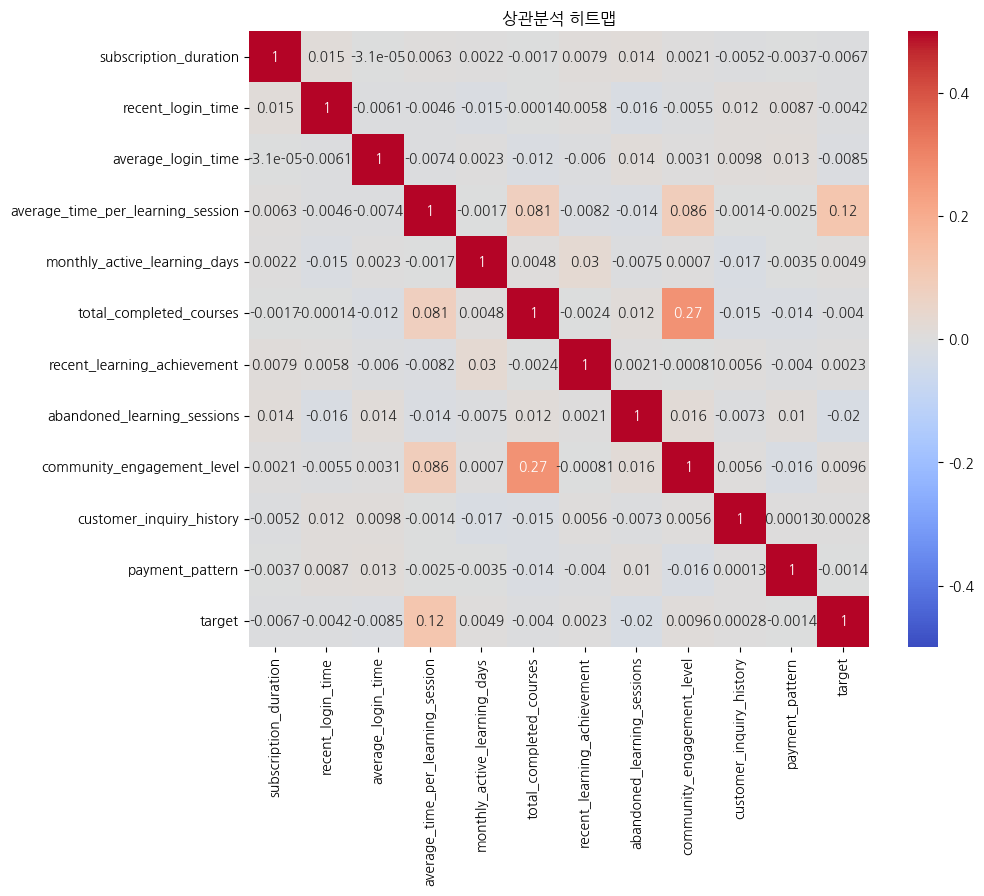

In [122]:
access_data2 = access_data.drop(columns=['user_id','preferred_difficulty_level','subscription_type'])
correlation_matrix = access_data2.corr()
correlation_matrix
# mask = correlation_matrix <= -0.019
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-0.5, vmax=0.5,) # mask=mask)
plt.title('상관분석 히트맵')
plt.show()

### 결과
* total_completed_courses와 community_engagement_level 의 상관관계가 가장 높습니다.
    * 이는 내부에서 활발하게 소통하는 것과 학습 코스를 완료하는 것이 상관이 있다는 것을 의미합니다.
* average_time_per_learning_session과 target의의 상관관계가 2번째로 높습니다.
    * 이는 각 학습 세션에 소요된 평균 시간과 익월에 구독을 계속하는 것이 상관이 있다는 것을 의미합니다.
* 또한 average_time_per_learning_session 은 total_completed_courses, community_engagement_level 과의 상관관계도 높습니다.



#### [상관관계] total_completed_courses ↔ community_engagement_level ↔ average_time_per_learning_session ↔ target
완료한 총 코스 수 ↔ 커뮤니티 참여도 ↔ 각 학습 세션에 소요된 평균 시간 (분) ↔ 익월 구독 여부



그림으로 표현하면 아래와 같습니다.

![nn](슬라이드1.png)

------

 ## 3. 문제인식, 방향성

 ### 3-1) 문제인식
    
    유저들의 학습 습관, 선호도, 이용 행태 등 다양한 측면을 면밀히 분석하여 누가 서비스를 계속 구독할지 사전 예측하는 것이 목표입니다.


 
 ### 3-2) 방향성
    메타데이터를 이용하여 다음과 같은 방향으로 문제를 해결하고자 합니다.
    
    1. 유저들이 서비스에 얼마나 만족하고 있을까?
    2. 어떤 요소들이 그들의 구독 결정에 영향을 미칠까?
    
    만족도가 높고 구독에 영향을 미치는 요소가 명확할수록 서비스를 계속 구독할 가능성이 높을 것으로 예상됩니다.

------

 ## 4. 1차 가설 세우기 및 검증

    가설 1. Target 1 과 Target 0 은 행동에서 차이점이 있을 것이다. 
        1-1) 각 학습 세션에 소요된 평균 시간은 Target 1이 더 길 것이다.
        1-2) 월간 활동적인 학습일 수와 커뮤니티 참여도가 높은 사람들은 Target 1일 것이다.
        1-3) 지난 3개월 동안 모두 결제한 사람은 이어서 구독할 가능성이 높을 것이다.

In [131]:
# 가설1 데이터 전처리
# Target 1(구독 연장) Target 0(구독 미연장) 데이터를 분리한다.
target0 = access_data[access_data['target'] != 1]
target0_describe = target0.describe()
target0_describe = target0_describe.transpose()
target1 = access_data[access_data['target'] != 0]
target1_describe = target1.describe()
target1_describe = target1_describe.transpose()
target0_describe

,count,mean,std,min,25%,50%,75%,max
subscription_duration,3801.0,11.953959,6.618295,1.000000,6.000000,12.000000,18.000000,23.000000
recent_login_time,3801.0,15.057880,8.428730,1.000000,8.000000,15.000000,22.000000,29.000000
average_login_time,3801.0,15.026762,2.956732,3.636424,13.077376,14.979239,17.030607,26.998490
average_time_per_learning_session,3801.0,46.456986,39.639733,0.011515,14.485582,34.773346,68.298309,179.176060
monthly_active_learning_days,3801.0,12.502236,6.854200,1.000000,7.000000,13.000000,18.000000,24.000000
total_completed_courses,3801.0,12.246251,3.630554,1.000000,10.000000,12.000000,15.000000,27.000000
recent_learning_achievement,3801.0,75.000310,9.873574,35.941755,68.316764,74.981448,81.520614,107.135153
abandoned_learning_sessions,3801.0,3.087609,1.755430,0.000000,2.000000,3.000000,4.000000,11.000000
community_engagement_level,3801.0,3.870560,1.259105,1.000000,3.000000,4.000000,5.000000,5.000000
customer_inquiry_history,3801.0,2.009997,1.409145,0.000000,1.000000,2.000000,3.000000,10.000000


In [123]:
# 타겟 집단 간의 평균값 비교
target0_mean = target0_describe.loc[:, ['mean']]
target0_mean.columns = ['타겟0 평균']
target1_mean = target1_describe.loc[:, ['mean']]
target1_mean.columns = ['타겟1 평균']

# 수치 범위가 달라서 범위가 비슷한 항목끼리 나눔
merged_df = pd.concat([target0_mean, target1_mean], axis=1)
merged_df = merged_df.sort_values(by='타겟1 평균')
merged_df1 = merged_df.iloc[1:5]  # 첫 번째 6개 행
merged_df2 = merged_df.iloc[5:10]  # 나머지 행
merged_df3 = merged_df.iloc[10:12]  # 나머지 행
print(merged_df1)
print(merged_df2)
print(merged_df3)

                               타겟0 평균    타겟1 평균
customer_inquiry_history     2.009997  2.010808
abandoned_learning_sessions  3.087609  3.016616
payment_pattern              3.506972  3.500403
community_engagement_level   3.870560  3.895628
                                 타겟0 평균     타겟1 평균
subscription_duration         11.953959  11.862720
total_completed_courses       12.246251  12.216003
monthly_active_learning_days  12.502236  12.571866
average_login_time            15.026762  14.974035
recent_login_time             15.057880  14.985804
                                      타겟0 평균     타겟1 평균
average_time_per_learning_session  46.456986  60.105533
recent_learning_achievement        75.000310  75.047419


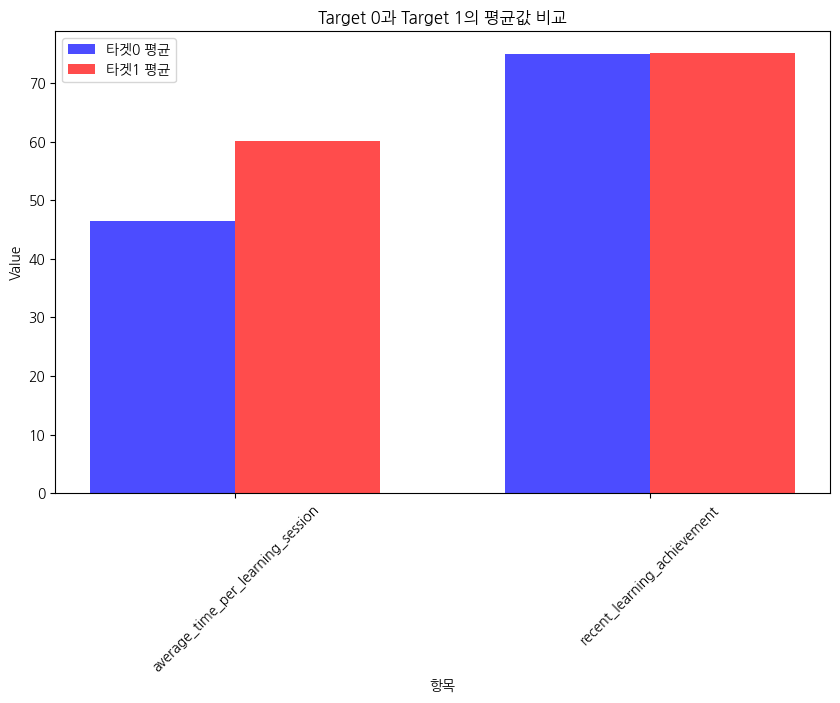

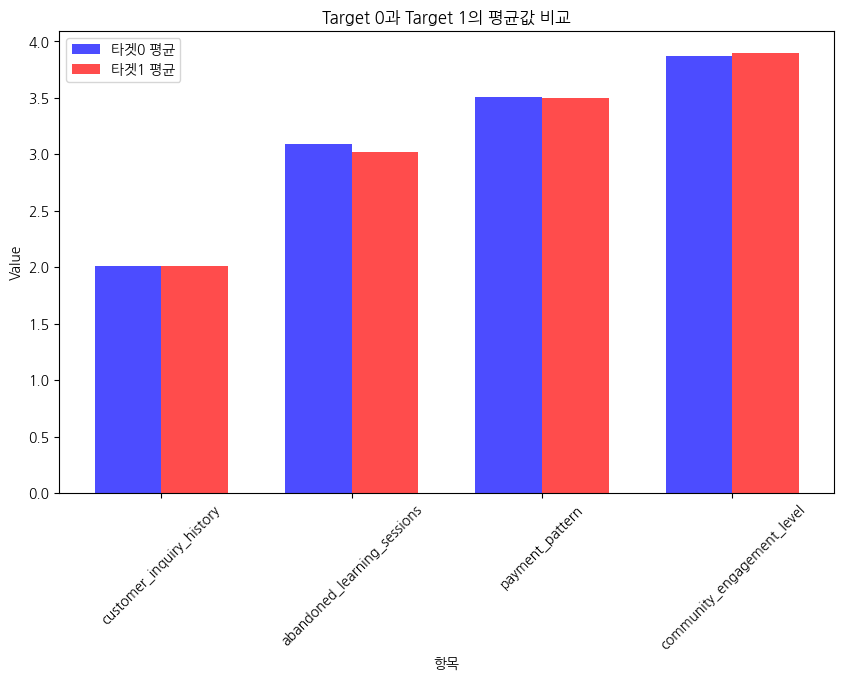

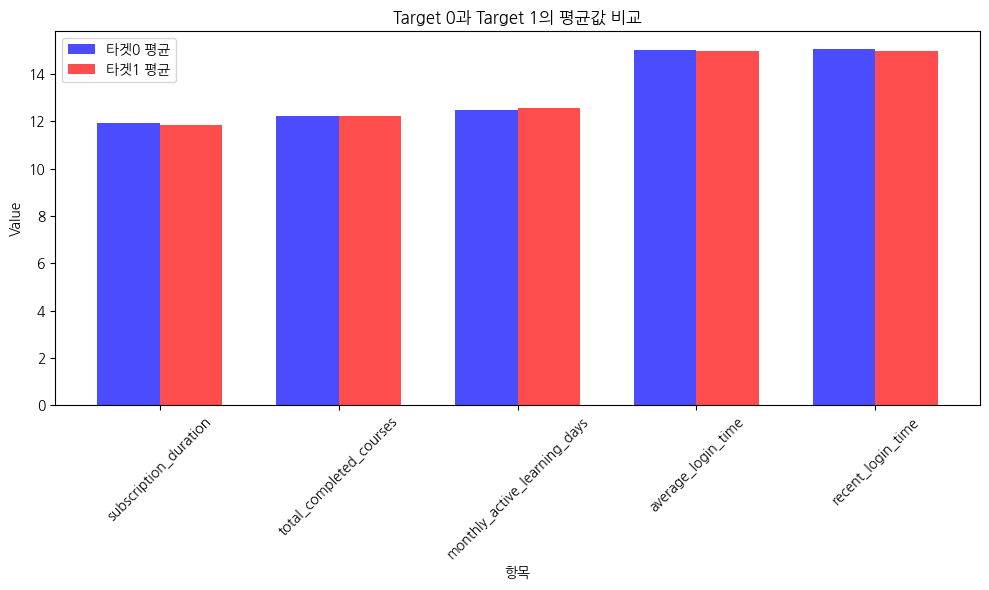

In [130]:
# 타겟 집단 간의 평균값 비교 시각화
# 막대 그래프 그리기
plt.figure(figsize=(10, 6))

# 막대 그래프 설정
bar_width = 0.35
index = range(len(merged_df3))
plt.bar(index, merged_df3['타겟0 평균'], width=bar_width, label='타겟0 평균', color='b', alpha=0.7)
plt.bar([i + bar_width for i in index], merged_df3['타겟1 평균'], width=bar_width, label='타겟1 평균', color='r', alpha=0.7)

# 축 및 레이블 설정
plt.xlabel('항목')
plt.ylabel('Value')
plt.title('Target 0과 Target 1의 평균값 비교')
plt.xticks([i + bar_width / 2 for i in index], merged_df3.index, rotation=45)
plt.legend()

# 막대 그래프 그리기
plt.figure(figsize=(10, 6))

# 막대 그래프 설정
bar_width = 0.35
index = range(len(merged_df1))
plt.bar(index, merged_df1['타겟0 평균'], width=bar_width, label='타겟0 평균', color='b', alpha=0.7)
plt.bar([i + bar_width for i in index], merged_df1['타겟1 평균'], width=bar_width, label='타겟1 평균', color='r', alpha=0.7)

# 축 및 레이블 설정
plt.xlabel('항목')
plt.ylabel('Value')
plt.title('Target 0과 Target 1의 평균값 비교')
plt.xticks([i + bar_width / 2 for i in index], merged_df1.index, rotation=45)
plt.legend()

# 막대 그래프 그리기
plt.figure(figsize=(10, 6))

# 막대 그래프 설정
bar_width = 0.35
index = range(len(merged_df2))
plt.bar(index, merged_df2['타겟0 평균'], width=bar_width, label='타겟0 평균', color='b', alpha=0.7)
plt.bar([i + bar_width for i in index], merged_df2['타겟1 평균'], width=bar_width, label='타겟1 평균', color='r', alpha=0.7)

# 축 및 레이블 설정
plt.xlabel('항목')
plt.ylabel('Value')
plt.title('Target 0과 Target 1의 평균값 비교')
plt.xticks([i + bar_width / 2 for i in index], merged_df2.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

 #### 1-1) 각 학습 세션에 소요된 평균 시간은 Target 1이 더 길 것이다.⭕

    average_time_per_learning_session 항목이 Target 1이 더 높은 것을 보았을때,
    구독을 연장하는 사람들은 한 세션에 평균 한시간 정도의 시간이 소요되며
    이는 구독을 연장하지 않는 사람들에 비해 약 14분정도 더 긴 시간입니다.

    
 #### 1-2) 월간 활동적인 학습일 수와 커뮤니티 참여도가 높은 사람들은 Target 1일 것이다.🔺
    그래프 상에서 monthly_active_learning_days와 community_engagement_level은 Target 1 집단이 더 높은 것은 사실입니다.
    하지만 1-1 가설만큼 큰 차이는 아니며, 수치 상으로도 차이가 미미하여 직접적인 영향이 있는 항목은 아닌 것으로 보여집니다.
    
    
 #### NEW) abandoned_learning_sessions 중단된 학습 세션 수는 Target 1이 더 적다.❗
    대부분의 항목들이 평균값 차이가 미미하였는데, 구독을 유지하는 사람들은 중단된 학습 세션이 비교적 적다는 것을 알게되었습니다.
    상관 분석 표로 돌아가보니 Target 과 abandoned_learning_sessions 상관관계 값은 -0.02로 음의 상관관계 중 가장 낮다는 것을 발견했습니다.
![nn](슬라이드2.png)

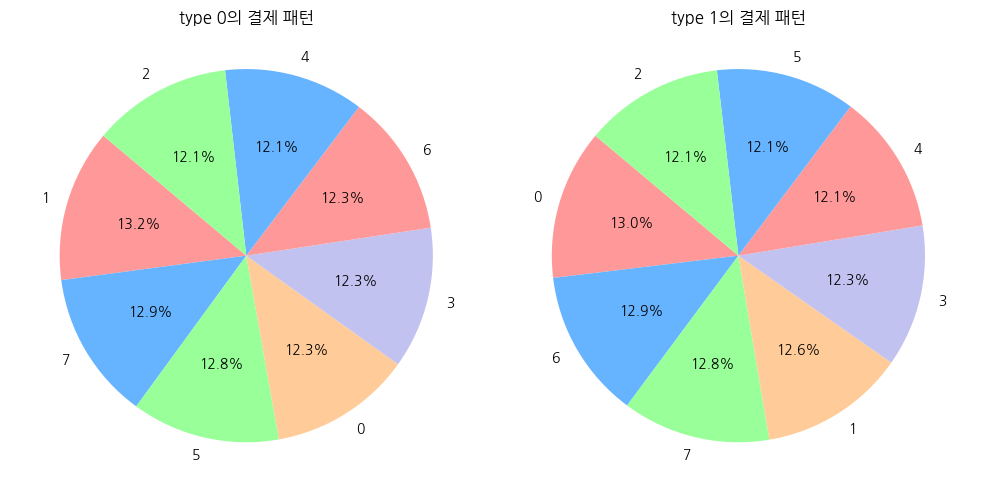

In [159]:
counts1 = target0['payment_pattern'].value_counts()
counts2 = target1['payment_pattern'].value_counts()

# 라벨과 사이즈 설정
labels1 = counts1.index
sizes1 = counts1.values

labels2 = counts2.index
sizes2 = counts2.values

# 색상 설정
# colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

# 서브플롯 생성 (1행 2열로 배치)
plt.figure(figsize=(10, 5))

# 첫 번째 원 그래프
plt.subplot(1, 2, 1)
plt.pie(sizes1, labels=labels1, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('type 0의 결제 패턴')
plt.axis('equal')

# 두 번째 원 그래프
plt.subplot(1, 2, 2)
plt.pie(sizes2, labels=labels2, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('type 1의 결제 패턴')
plt.axis('equal')

# 서브플롯 간 간격 조정
plt.tight_layout()

# 그래프 출력
plt.show()

 #### 1-3) 지난 3개월 동안 모두 결제한 사람은 이어서 구독할 가능성이 높을 것이다. ❌
    지난 3개월 동안 모두 결제한 패턴은 7번인데, 비교를 할 필요가 없을 정도로 
    구독 유지한 사람과 아닌 사람의 결제 패턴 비율이 거의 비슷합니다.
    오히려 한번도 결제를 하지 않은 type 1 - 0번 패턴의 비중이 약간 높게 나왔으나,
    메타 데이터 내에서 3개월 간 결제를 한번도 하지 않은 사람도 구독 유형이 표기되는 것을 보았을때
    "구독 = 결제"는 성립하지 않기 때문에 3개월 간의 결제 데이터와 구독 간의 상관성은 없는 것으로 판단됩니다.
----
 ## 5. 1차 결론
    * 구독 여부와 직접적인 연관성이 있는 데이터는 abandoned_learning_sessions, average_time_per_learning_session입니다.
    * 세션 중간에 이탈하지 않고 끝낼 수 있도록 독려하는 것이 중요합니다.
        예) 중간중간에 퀴즈를 내고 학습을 이어갈 수 있도록 응원, 프로필에 정답율을 표기하여 세션 학습 시간 증가와 커뮤니티 참여도를 함께 높이는 방법을 기획
-----

 # 의상파 : 왜 38% 사람들은 구독을 취소했을까요?

    1만명의 구독자 중 3,801명은 구독을 유지하지 않았습니다. 38%의 사람들이 이탈하는 이유는 무엇일까요?
    어떤 것에 불만족한 것 일까요? 처음에 그렸던 상관관계 이미지를 다시 가져와보겠습니다.
 
![nn](슬라이드2.png)

    
    
    1차 가설 검증을 통해 오른쪽 3개 항목이 가장 높은 상관관계에 있고, 각 학습 세션에 소요된 평균 시간이 길수록, 구독을 유지하는 경향이 있다는 것을 알게 되었습니다.
    그렇다면 Target 1(구독유지)집단이 보다 오래 공부한 이유가 뭘까요? 다양한 이유가 있겠지만 1. 나에게 필요한 공부여서 몰입 2. 이해가 안되는 점이 있어서(= 어려움을 느껴서)
    2개로 생각해볼 수 있습니다. (유저리서치를 한다면 정확하게 알 수 있겠죠.) 그리고 커뮤니티의 도움을 주고 받아 문제를 해결했고, 덕분에 완료한 코스가 많다고 볼 수 있지않을까요?

![nn](슬라이드3.png)

    그리하여 이 3개 항목의 긍정적인 선순환이 잘 이루어질때 구독을 유지한다고 생각할 수 있을 것 같습니다. 이것을 "열공 써클"이라고 이름 지어보겠습니다.

    덧붙여 1차 가설 검증 중, 중단된 학습 세션 수 항목이 구독 여부와 음의 상관관계를 이루고 있었습니다. 학습세션을 중단한 이유는 무엇일까요?
    (이것도 유저리서치하면 좋을 것 같네요.) 우선 생각해볼 수 있는 것은 1. 너무 쉬웠다. 2. 필요없었다. 3. 너무 어려워서 중도포기 가 될 수 있을 것 같습니다.

    난이도와 관련이 높은 두 개 항목을 검증하기 위해 다음과 같은 2차 가설을 세워보겠습니다.
    
### 6. 2차 가설
    가설 2-1) Target 0 집단의 선호 난이도는 양쪽으로 치우쳐져 있을 것이다.
    가설 2-2) Target 0 집단은 Target 1 집단에 비해 열공 써클에 문제가 있을 것이다.
    Target 0 집단의 선호 난이도가 높은 군은 각 학습 세션에 소요된 평균 시간이 낮을 것이다. (쉬우니까) 
    가설 2-3) Target 0 집단의 선호 난이도가 낮은 군은 성취도가 낮을 것이다.(포기함)

-----
### 7. 가설 검증

preferred_difficulty_level
Low       1945
Medium    1097
High       759
Name: count, dtype: int64


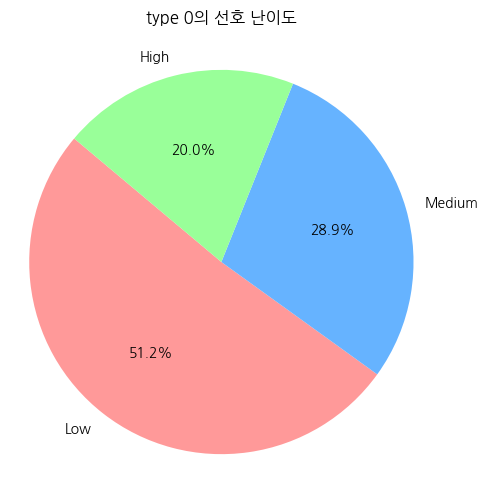

In [196]:
counts3 = target0['preferred_difficulty_level'].value_counts()
print(counts3)
# 라벨과 사이즈 설정
labels3 = counts3.index
sizes3 = counts3.values

# 색상 설정
# colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

# 서브플롯 생성 (1행 2열로 배치)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.pie(sizes3, labels=labels3, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('type 0의 선호 난이도')
plt.axis('equal')
plt.show()

 #### 가설 2-1) Target 0 집단의 선호 난이도는 양쪽으로 치우쳐져 있을 것이다. 🔺
    * Low를 선호하는 사람이 1,945명 51.2%로 전체의 절반 이상이며, 가장 많았습니다.
    * High를 선호하는 사람은 759명 20%이며 Low와 High를 합치면 71.2%로 일반적인 비율인 66.6%보다 4.6% 높습니다.
    * 하지만 Target 1 집단의 비율과 그리 다르지 않다는 게 함정...^_ㅜ

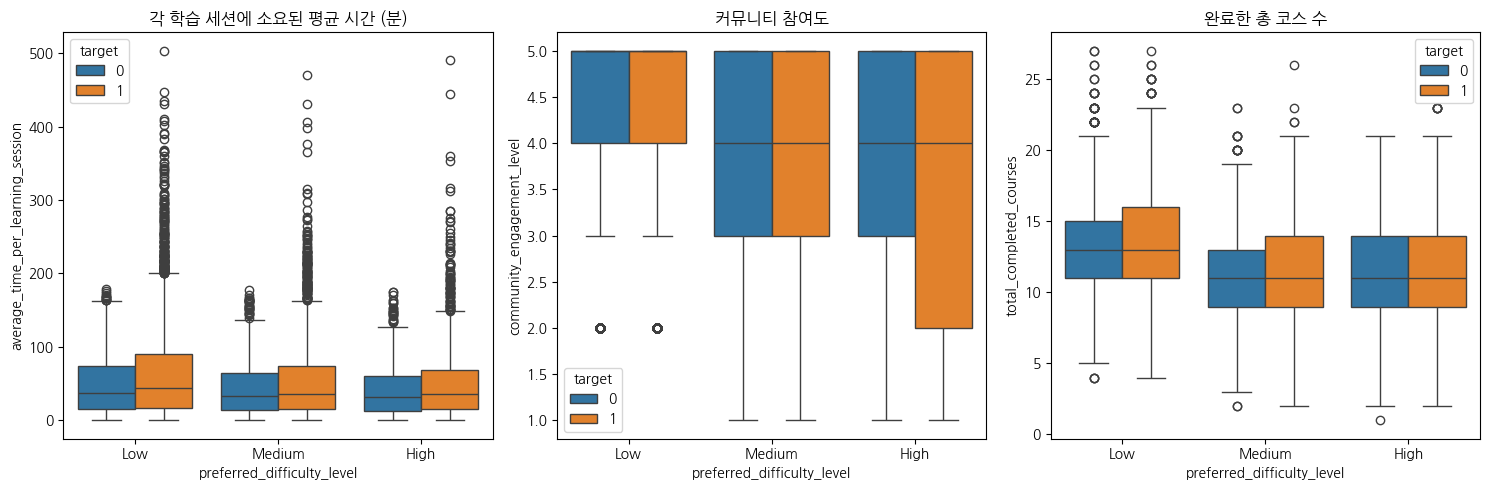

In [226]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
sns.boxplot(ax=axes[0] , x="preferred_difficulty_level", y="average_time_per_learning_session", hue="target", data=access_data)
axes[0].set_title('각 학습 세션에 소요된 평균 시간 (분)')
axes[0].set_ylabel('average_time_per_learning_session')

sns.boxplot(ax=axes[1] , x="preferred_difficulty_level", y="community_engagement_level", hue="target", data=access_data)
axes[1].set_title('커뮤니티 참여도')
axes[1].set_ylabel('community_engagement_level')

sns.boxplot(ax=axes[2] , x="preferred_difficulty_level", y="total_completed_courses", hue="target", data=access_data)
axes[2].set_title('완료한 총 코스 수')
axes[2].set_ylabel('total_completed_courses')

plt.tight_layout()
plt.show()

 #### 가설 2-2) Target 0 집단은 Target 1 집단에 비해 열공 써클에 문제가 있을 것이다. ⭕
    * 각 학습 세션에 소요된 평균 시간 (분)
        * 박스값과 분포로 보았을 때, Target 0 집단이 Target 1 집단보다 평균 시간이 짧은 것을 알 수 있습니다.
        * 그러나 Target 1 집단에 이상치가 너무 많은 것이, 다중 로그인, 여러 명이 한 아이디 사용을 의심해볼 수 있습니다.
    * 커뮤니티 참여도
        * 커뮤니티 참여도는 거의 비슷한 형태를 띄고 있습니다.
        * 오히려 선호 난이도 High 군에서는 Target 0 집단의 박스값이 더 높습니다.
    * 완료한 총 코스 수
        * 박스값과 분포로 보았을 때, Target 1 집단이 더 많은 코스를 완료하거나 같은 것으로 보여집니다.

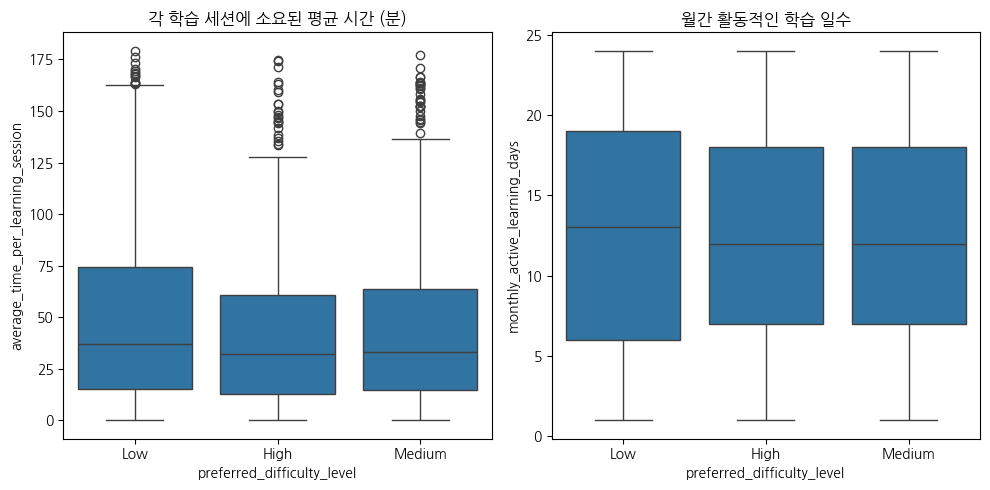

In [235]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(ax=axes[0] , x="preferred_difficulty_level", y="average_time_per_learning_session", data=target0)
axes[0].set_title('각 학습 세션에 소요된 평균 시간 (분)')
axes[0].set_ylabel('average_time_per_learning_session')

sns.boxplot(ax=axes[1] , x="preferred_difficulty_level", y="monthly_active_learning_days", data=target0)
axes[1].set_title('월간 활동적인 학습 일수')
axes[1].set_ylabel('monthly_active_learning_days')

plt.tight_layout()
plt.show()

 #### 가설 2-3) Target 0 집단의 선호 난이도 Low군 보다 High군의 학습 시간이 더 짧을 것이다. ⭕
    * 각 학습 세션에 소요된 평균 시간 (분)과 월간 활동적인 학습 일수로 비교하였습니다.
    * 두 개의 표 모두 Low군 보다 High군의 학습 시간, 일수가 짧은 것을 알 수 있었습니다.

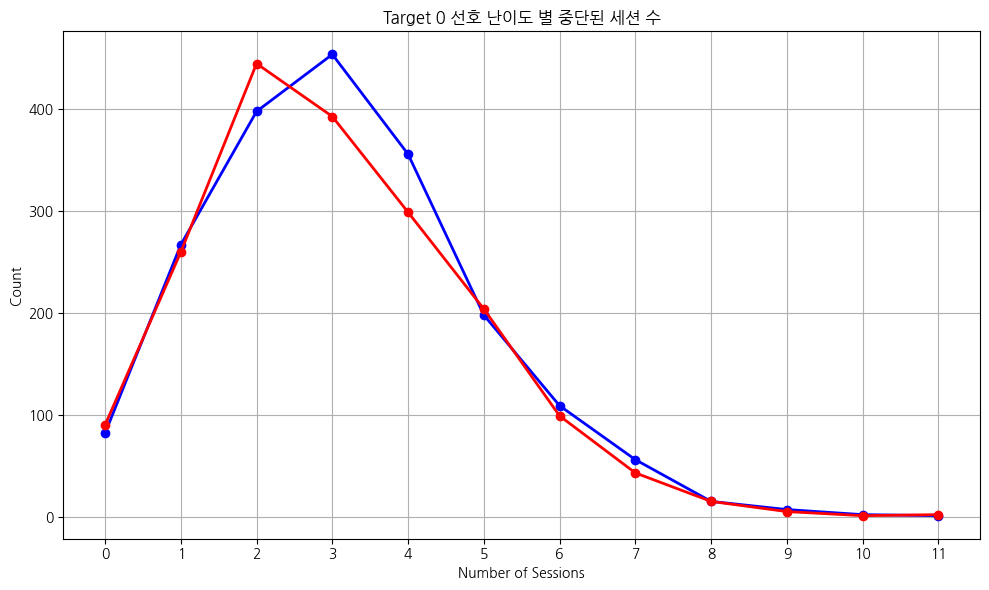

In [261]:
target0_low = target0[target0['preferred_difficulty_level'].isin(['Low'])]
counts4 = target0_low['abandoned_learning_sessions'].value_counts()
counts4 = counts4.sort_index()
target0_High_Medium = target0[target0['preferred_difficulty_level'].isin(['High','Medium'])]
counts5 = target0_High_Medium['abandoned_learning_sessions'].value_counts()
counts5 = counts5.sort_index()

# Extract sessions and count from counts4
sessions = counts4.index
count4 = counts4.values
count5 = counts5.values

# Plotting the line plot
plt.figure(figsize=(10, 6))
plt.plot(sessions, count4, marker='o', linestyle='-', color='b', linewidth=2)
plt.plot(sessions, count5, marker='o', linestyle='-', color='r', linewidth=2)

# Adding labels and title
plt.title('Target 0 선호 난이도 별 중단된 세션 수')
plt.xlabel('Number of Sessions')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(sessions)  # x-axis ticks based on session values
plt.tight_layout()

# Display the plot
plt.show()

 #### 가설 2-4) Target 0 집단의 선호 난이도 High군 보다 Low군의 중단된 학습 세션 수가 많을 것이다. ⭕
    * 전반적으로 비슷한 양상을 띄고 있습니다.
    * 그러나 중단된 학습세션 중 최대값은 Low군이 3번, 그 외 군이 2번으로 그 외 군이 조금 더 적은 것을 확인했습니다.

----
 ## 8. 결과
    구독 여부와 직접적인 연관이 있는 세션당 소요된 평균 시간을 늘리기 위해 High, Medium 군을 위한 수준 높은 컨텐츠가 필요합니다.
    구독 취소-Low 군은 구독을 유지하는 집단에 비해 전반적으로 수치가 낮고 다른 선호 난이도 군보다 좀 더 많이 세션을 중단합니다. 
    그러나 커뮤니티 참여 레벨은 높으므로 이것을 이용하여 Low 군의 문제나 어려움을 해결해줄 수 있는 멘토진을 커뮤니티에 배치하여 
    즉각적, 유기적으로 피드백해줄 수 있다면 열공 써클이 정상 순환할 것으로 생각됩니다.
 
 ### 9. 추가할 점
    가설 검증의 신뢰성을 위해서 유저리서치를 병행한다면 효과적일 것입니다. 세션 중단 시 바로 팝업으로 중단 이유에 대한 간단한 체크 박스 설문을 만든다면 어떨까요?
    우리가 목표하는 바는 어떤 사람이 계속 구독할 것인지를 예측하는 것이므로 유저리서치를 통해 열공써클에 대한 신뢰도가 생긴다면 
    각 항목에 가중치를 두어 구독관련 점수를 파생변수로 두는 것도 좋을 것 같습니다. 예) 80점이상 구독 유지 가능성 높음, 80점 이하 구독 취소 가능성 높음

 # 감사합니다!